# 02_baseline_cnn.ipynb — HistoBreastNet

CNN **addestrata da zero**, usata come baseline per la classificazione binaria benigno/maligno. Il notebook **consuma** gli split e le fold prodotti da `01_preprocessing.ipynb` (config `diversity_1p5GB`) e **non li rigenera**: gli stessi file sono la base comune anche per gli esperimenti successivi.

**Cosa produce**
- Baseline CNN valutata su tre protocolli: image-wise, patient-wise, k-fold patient-wise (k=5).
- Metriche predittive: accuracy, precision (macro), recall (macro), F1 (macro), AUROC, recall della classe maligna (sensibilità clinica), confusion matrix.
- Metriche di efficienza: numero di parametri, tempo totale e medio per epoca di training, tempo di inferenza per immagine, dimensione del modello su disco.
- Tabella finale `results/02_baseline_cnn/tables/cnn_baseline_metrics.csv` (schema fisso) e sintesi k-fold (media ± std).

**Nota sulla valutazione.** Con pochi pazienti il singolo split patient-wise ha varianza elevata: il riferimento per la generalizzazione a pazienti non visti è la **k-fold patient-wise** (media ± std), non il singolo split.

## Sezione 0 — Setup, path, riproducibilità

Import delle librerie, montaggio di Google Drive, impostazione dei seed per la riproducibilità e definizione dei path di progetto e degli iperparametri della baseline. Il flag `LOAD_EXISTING_MODELS_ONLY` distingue tra la riesecuzione del training e il semplice caricamento dei modelli già addestrati.

In [3]:
import os, sys, gc, time, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

# ----- Riproducibilita ------------------------------------------------------
RANDOM_STATE = 42
os.environ['PYTHONHASHSEED'] = str(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)
# Determinismo completo (piu lento): scommenta se serve bit-per-bit reproducibility.
# tf.config.experimental.enable_op_determinism()

# ----- Path progetto --------------------------------------------------------
PROJECT_ROOT   = Path('/content/drive/MyDrive/HistoBreastNet')
DATA_PROCESSED = PROJECT_ROOT/'data'/'processed'
CONFIG_NAME    = 'diversity_1p5GB'            # config principale per la baseline
CONFIG_DIR     = DATA_PROCESSED/CONFIG_NAME
RESULTS_DIR     = PROJECT_ROOT/'results'
NB_RESULTS_DIR  = RESULTS_DIR/'02_baseline_cnn'   # tutti gli output di questo notebook qui sotto
TABLES_DIR      = NB_RESULTS_DIR/'tables'
FIGURES_DIR     = NB_RESULTS_DIR/'figures'
PREDICTIONS_DIR = NB_RESULTS_DIR/'predictions'    # predizioni per-immagine (per la ROC del notebook 03)
EXPERIMENTS_DIR = PROJECT_ROOT/'experiments'      # una sottocartella per run (una per esperimento)
for d in (TABLES_DIR, FIGURES_DIR, PREDICTIONS_DIR, EXPERIMENTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Modalità: solo predizioni da modelli salvati (nessun nuovo training) ---
LOAD_EXISTING_MODELS_ONLY = True
# True  = non riesegue il training; carica i model.keras già salvati e genera solo le predizioni.
# False = esegue il training completo della CNN baseline.

assert CONFIG_DIR.exists(), f'Config non trovata: {CONFIG_DIR} (esegui prima 01_preprocessing).'

# ----- Iperparametri baseline ----------------------------------------------
IMG_SIZE   = 224
BATCH_SIZE = 32
EPOCHS     = 40            # limite superiore; EarlyStopping ferma prima
PATIENCE   = 8
QUICK_TEST = False         # True = giro rapido per validare la pipeline (2 epoche)
if QUICK_TEST:
    EPOCHS, PATIENCE = 2, 2

AUTOTUNE = tf.data.AUTOTUNE
gpus = tf.config.list_physical_devices('GPU')
print('TF', tf.__version__, '| GPU:', gpus if gpus else 'NESSUNA (attiva runtime GPU su Colab)')
print('Config baseline:', CONFIG_NAME)

Mounted at /content/drive
TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Config baseline: diversity_1p5GB


## Sezione 1 — Disponibilità del subset (immagini)

La baseline legge **solo** le immagini del subset `diversity_1p5GB` prodotte da `01_preprocessing.ipynb`, in `data/processed/diversity_1p5GB/images/`, e **non** l'intero dataset BreaKHis. I `relative_path` dei CSV partono da `histology_slides/...`, quindi la root si risolve come `DATASET_ROOT / relative_path`.

`READ_MODE`:
- `auto` (default): se esiste `images.zip` su Drive lo estrae in `/content/` (lettura veloce); altrimenti legge direttamente dalla cartella `images/` su Drive (più lento, senza zip);
- `zip`: forza l'estrazione da `images.zip`;
- `drive`: forza la lettura diretta dalla cartella `images/` su Drive.

Se il runtime si disconnette durante l'estrazione è sufficiente rilanciare la cella.

In [4]:
import zipfile, shutil

# Sorgente = subset creato dal 01 (Sezione 7). NIENTE dataset completo.
SUBSET_IMAGES_DRIVE = CONFIG_DIR/'images'          # data/processed/diversity_1p5GB/images (su Drive)
SUBSET_IMAGES_ZIP   = CONFIG_DIR/'images.zip'      # zip opzionale prodotto dal 01
SUBSET_LOCAL        = Path('/content/subset_images')   # destinazione estrazione veloce

# 'auto' -> zip se presente, altrimenti Drive | 'zip' -> forza zip | 'drive' -> forza Drive
READ_MODE = 'auto'

def _resolve_root(base):
    """La root deve contenere DIRETTAMENTE histology_slides/ (gestisce il prefisso images/)."""
    if (base/'histology_slides').exists():
        return base
    if (base/'images'/'histology_slides').exists():
        return base/'images'
    return None

if READ_MODE == 'zip' and not SUBSET_IMAGES_ZIP.exists():
    raise FileNotFoundError(f'READ_MODE=zip ma manca {SUBSET_IMAGES_ZIP}. '
                            'Crea lo zip nel 01 (Sezione 7, CREATE_IMAGES_ZIP=True).')

use_zip = (READ_MODE in ('auto', 'zip')) and SUBSET_IMAGES_ZIP.exists()

if use_zip:
    shutil.rmtree(SUBSET_LOCAL, ignore_errors=True)
    SUBSET_LOCAL.mkdir(parents=True, exist_ok=True)
    t0 = time.time(); print('Estrazione del subset dallo zip su Drive...')
    with zipfile.ZipFile(SUBSET_IMAGES_ZIP) as z:
        z.extractall(SUBSET_LOCAL)
    DATASET_ROOT = _resolve_root(SUBSET_LOCAL)
    print('Subset estratto in %.0fs -> %s' % (time.time()-t0, DATASET_ROOT))
elif SUBSET_IMAGES_DRIVE.exists():
    DATASET_ROOT = _resolve_root(SUBSET_IMAGES_DRIVE)
    print('Lettura diretta dal subset su Drive (più lento):', SUBSET_IMAGES_DRIVE)
else:
    raise FileNotFoundError(
        'Subset non trovato. Esegui prima 01_preprocessing.ipynb (Sezione 7) per creare '
        f'{SUBSET_IMAGES_DRIVE} (e opzionalmente {SUBSET_IMAGES_ZIP}).')

if DATASET_ROOT is None:
    raise FileNotFoundError('Non trovo histology_slides/ nel subset: struttura inattesa.')

# Integrità: il numero di PNG deve combaciare con metadata_subset.csv (subset, non 7909)
n_sub = sum(1 for _ in DATASET_ROOT.rglob('*.png'))
n_csv = len(pd.read_csv(CONFIG_DIR/'metadata_subset.csv'))
assert n_sub == n_csv, f'Subset incompleto: {n_sub} PNG trovati, {n_csv} attesi (metadata_subset.csv).'
print('DATASET_ROOT:', DATASET_ROOT, '| immagini subset:', n_sub, '-> OK ✓')

Estrazione del subset dallo zip su Drive...
Subset estratto in 39s -> /content/subset_images/images
DATASET_ROOT: /content/subset_images/images | immagini subset: 2838 -> OK ✓


## Sezione 2 — Caricamento degli split/fold e ricostruzione dei path

Si leggono i CSV della configurazione e si ricostruisce il path assoluto a partire da `relative_path` (`full_path = DATASET_ROOT / relative_path`). I path assoluti salvati dal notebook 01 (colonna `path`) vengono ignorati, così il notebook resta portabile tra sessioni diverse.

In [5]:
def add_full_path(df):
    """Aggiunge full_path da relative_path e resetta l'indice (ordine stabile)."""
    df = df.copy()
    df['full_path'] = df['relative_path'].map(lambda r: str(DATASET_ROOT / r))
    return df.reset_index(drop=True)

# Sanity: i file referenziati esistono davvero
_probe = add_full_path(pd.read_csv(CONFIG_DIR/'metadata_subset.csv'))
_missing = [p for p in _probe['full_path'].sample(min(50, len(_probe)), random_state=RANDOM_STATE)
            if not Path(p).exists()]
assert not _missing, f'File non trovati (esempio): {_missing[:3]}'
print('metadata_subset:', len(_probe), 'immagini |', _probe['patient_id'].nunique(), 'pazienti')
print('Distribuzione classi (immagini):', _probe['binary_label'].value_counts().to_dict(),
      ' (0=benign, 1=malignant)')

with open(CONFIG_DIR/'config.json') as f:
    CFG = json.load(f)
print('config.json ->', {k: CFG[k] for k in
      ('n_patients','n_images','actual_size_gib','n_patients_benign','n_patients_malignant')})

metadata_subset: 2838 immagini | 33 pazienti
Distribuzione classi (immagini): {0: 1431, 1: 1407}  (0=benign, 1=malignant)
config.json -> {'n_patients': 33, 'n_images': 2838, 'actual_size_gib': 1.483, 'n_patients_benign': 15, 'n_patients_malignant': 18}


## Sezione 3 — Pipeline `tf.data`

Decodifica PNG → resize 224×224 → cache in `uint8` (memoria-efficiente) → normalizzazione in [0,1]. L'augmentation (flip e variazioni leggere di luminosità e contrasto) è applicata **solo al training**. Validation e test non vengono mescolati: l'ordine delle predizioni coincide con quello dei DataFrame, condizione necessaria per associare correttamente ogni predizione alla sua immagine.

In [6]:
def _decode_uint8(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE], method='bilinear')
    img = tf.cast(img, tf.uint8)                      # cache leggera (~1 byte/px)
    return img, label

def _to_float(img, label):
    return tf.cast(img, tf.float32) / 255.0, label

def _augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, 0.05)
    img = tf.image.random_contrast(img, 0.95, 1.05)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_ds(df, training=False, augment=False, batch=BATCH_SIZE):
    paths  = df['full_path'].values
    labels = df['binary_label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(_decode_uint8, num_parallel_calls=AUTOTUNE).cache()
    # shuffle solo in training; su validation/test l'ordine resta stabile
    # per mantenere l'allineamento tra predizioni e righe del DataFrame.
    if training:
        ds = ds.shuffle(min(len(df), 2048), seed=RANDOM_STATE, reshuffle_each_iteration=True)
    ds = ds.map(_to_float, num_parallel_calls=AUTOTUNE)
    # augmentation applicata dopo la normalizzazione e solo quando richiesta.
    if augment:
        ds = ds.map(_augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(batch).prefetch(AUTOTUNE)

## Sezione 4 — Architettura CNN da zero e training

CNN volutamente compatta (4 blocchi Conv-BN-ReLU-Pool, seguiti da global average pooling e da una testa densa), adeguata a un dataset di dimensioni ridotte per limitare l'overfitting. L'uscita è sigmoide (classificazione binaria). Il `class_weight` bilanciato evita di penalizzare la classe maligna, sotto-rappresentata. L'`EarlyStopping` monitora `val_auc` e ripristina i pesi migliori.

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

def build_baseline_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), seed=RANDOM_STATE):
    keras.utils.set_random_seed(seed)               # init pesi riproducibile
    inp = layers.Input(shape=input_shape)
    x = inp
    # quattro blocchi convoluzionali a filtri crescenti; BatchNormalization
    # stabilizza il training, il pooling riduce progressivamente la risoluzione.
    for f in (32, 64, 128, 128):
        x = layers.Conv2D(f, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation('relu')(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.40)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.30)(x)
    # singola uscita sigmoide: probabilità della classe maligna.
    out = layers.Dense(1, activation='sigmoid')(x)
    return models.Model(inp, out, name='baseline_cnn')

class TimeHistory(keras.callbacks.Callback):
    """Registra il tempo di ogni epoca per calcolare avg_epoch_time_sec."""
    def on_train_begin(self, logs=None): self.times = []
    def on_epoch_begin(self, epoch, logs=None): self._t = time.time()
    def on_epoch_end(self, epoch, logs=None): self.times.append(time.time() - self._t)

def class_weights_from(df):
    y = df['binary_label'].values
    w = compute_class_weight('balanced', classes=np.array([0, 1]), y=y)
    return {0: float(w[0]), 1: float(w[1])}

def train_cnn(train_df, val_df, seed=RANDOM_STATE):
    train_ds = make_ds(train_df, training=True, augment=True)
    val_ds   = make_ds(val_df,   training=False, augment=False)
    model = build_baseline_cnn(seed=seed)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss='binary_crossentropy',
                  metrics=[keras.metrics.AUC(name='auc'), 'accuracy'])
    th = TimeHistory()
    # EarlyStopping su val_auc (robusta allo sbilanciamento) con ripristino dei pesi
    # migliori; ReduceLROnPlateau riduce il learning rate quando la val_loss ristagna.
    cbs = [keras.callbacks.EarlyStopping(monitor='val_auc', mode='max',
                                         patience=PATIENCE, restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                             patience=4, min_lr=1e-5),
           th]
    t0 = time.time()
    hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS,
                     class_weight=class_weights_from(train_df), callbacks=cbs, verbose=2)
    train_time = time.time() - t0
    return model, hist, th, train_time

## Sezione 5 — Metriche predittive, efficienza e valutazione

**Convenzione sulle metriche.** `precision`, `recall` e `f1` sono calcolate in modalità **macro** (media sulle due classi, vista bilanciata); `recall_malignant` è la recall della sola classe maligna (sensibilità, metrica clinicamente critica); `auroc` è calcolata sulle probabilità. La confusion matrix è salvata come `tn`/`fp`/`fn`/`tp`.

**Efficienza (D1).** `n_params` dal modello; `training_time_sec` misurato a muro; `avg_epoch_time_sec` come media reale delle epoche eseguite; `inference_time_ms_per_image` come throughput a regime su batch (preceduto da un warm-up); `model_size_mb` dalla dimensione del file `.keras` salvato su disco.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix)
from datetime import datetime

# --- Esperimenti: una cartella per run in experiments/ ----------------------
# Convenzione di naming della cartella:
#   <YYYYMMDD_HHMMSS_micros>_<dataset_config>_<split_type>_baseline_cnn_scratch_fold<N>
# Contenuto: config.json, model.keras, training_log.csv, metrics.csv
def make_experiment_dir(split_type, fold):
    fold_tag = 'NA' if pd.isna(fold) else int(fold)
    ts = datetime.now().strftime('%Y%m%d_%H%M%S_%f')
    name = f'{ts}_{CONFIG_NAME}_{split_type}_baseline_cnn_scratch_fold{fold_tag}'
    d = EXPERIMENTS_DIR/name
    d.mkdir(parents=True, exist_ok=True)
    return d

def save_training_log(exp_dir, hist, th):
    log = pd.DataFrame(hist.history)
    log.insert(0, 'epoch', range(1, len(log) + 1))
    if th.times and len(th.times) == len(log):
        log['epoch_time_sec'] = th.times
    log.to_csv(exp_dir/'training_log.csv', index=False)

def save_experiment_config(exp_dir, split_type, fold, sizes):
    cfg = dict(
        dataset_config=CONFIG_NAME, split_type=split_type,
        fold=(None if pd.isna(fold) else int(fold)),
        model='baseline_cnn', training_mode='from_scratch',
        image_size=[IMG_SIZE, IMG_SIZE], batch_size=BATCH_SIZE, seed=RANDOM_STATE,
        max_epochs=EPOCHS, patience=PATIENCE,
        optimizer='adam', learning_rate=1e-3, loss='binary_crossentropy',
        class_weight='balanced', quick_test=QUICK_TEST,
        source_config_dir=str(CONFIG_DIR),
        **sizes,
    )
    with open(exp_dir/'config.json', 'w') as f:
        json.dump(cfg, f, indent=2)


# Metriche predittive: versione macro (vista bilanciata sulle due classi) piu'
# la recall della sola classe maligna, clinicamente prioritaria.
def compute_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    out = dict(
        accuracy=accuracy_score(y_true, y_pred),
        precision=precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall=recall_score(y_true, y_pred, average='macro', zero_division=0),
        f1=f1_score(y_true, y_pred, average='macro', zero_division=0),
        recall_malignant=recall_score(y_true, y_pred, pos_label=1, zero_division=0),
    )
    try:
        out['auroc'] = roc_auc_score(y_true, y_prob)
    except ValueError:                                # test con una sola classe
        out['auroc'] = np.nan
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    out.update(tn=int(tn), fp=int(fp), fn=int(fn), tp=int(tp))
    return out

def measure_inference_ms(model, test_ds, n_images):
    _ = model.predict(test_ds, verbose=0)             # warm-up (grafo/JIT)
    t0 = time.perf_counter()
    _ = model.predict(test_ds, verbose=0)
    return (time.perf_counter() - t0) * 1000.0 / n_images

def run_cnn(split_type, fold, train_df, val_df, test_df):
    tf.keras.backend.clear_session()
    model, hist, th, train_time = train_cnn(train_df, val_df)

    test_ds = make_ds(test_df, training=False, augment=False)
    y_true  = test_df['binary_label'].values
    y_prob  = model.predict(test_ds, verbose=0).ravel()

    fold_tag = 'NA' if pd.isna(fold) else int(fold)
    exp_dir  = make_experiment_dir(split_type, fold)      # experiments/<timestamp>_.../
    ckpt = exp_dir/'model.keras'
    model.save(ckpt)
    sizes = dict(n_train=len(train_df), n_val=len(val_df), n_test=len(test_df))
    save_training_log(exp_dir, hist, th)                  # training_log.csv (andamento fit)
    save_experiment_config(exp_dir, split_type, fold, sizes)  # config.json (iperparametri)

    row = dict(dataset_config=CONFIG_NAME, split_type=split_type, fold=fold,
               model='baseline_cnn', training_mode='from_scratch',
               experiment=exp_dir.name)
    row.update(compute_metrics(y_true, y_prob))
    row.update(
        training_time_sec=round(train_time, 2),
        avg_epoch_time_sec=round(float(np.mean(th.times)), 2) if th.times else np.nan,
        inference_time_ms_per_image=round(measure_inference_ms(model, test_ds, len(test_df)), 3),
        n_params=int(model.count_params()),
        model_size_mb=round(ckpt.stat().st_size / 1e6, 2),
        n_train=len(train_df), n_val=len(val_df), n_test=len(test_df),
        epochs_run=len(th.times), notes='',
    )
    pd.DataFrame([row]).to_csv(exp_dir/'metrics.csv', index=False)  # metriche del singolo run
    print(f'[CNN] {split_type} fold={fold_tag}: '
          f"AUROC={row['auroc'] if pd.isna(row['auroc']) else round(row['auroc'],3)} "
          f"acc={row['accuracy']:.3f} rec_mal={row['recall_malignant']:.3f} "
          f"({row['epochs_run']} epoche, {row['training_time_sec']:.0f}s)")
    del model; gc.collect()
    return row

## Sezione 6 — Enumerazione dei protocolli di valutazione

Viene costruita un'unica lista di run `(split_type, fold, train, val, test)` **esclusivamente** a partire dai CSV prodotti dal notebook 01: image-wise (1 split), patient-wise (1 split) e k-fold patient-wise (5 fold). Nessuno split viene rigenerato in questo notebook.

In [7]:
def enumerate_runs():
    runs = []

    iw = add_full_path(pd.read_csv(CONFIG_DIR/'image_wise_split.csv'))
    runs.append(('image_wise', np.nan,
                 iw[iw.split=='train'], iw[iw.split=='val'], iw[iw.split=='test']))

    pw = add_full_path(pd.read_csv(CONFIG_DIR/'patient_wise_split.csv'))
    runs.append(('patient_wise', np.nan,
                 pw[pw.split=='train'], pw[pw.split=='val'], pw[pw.split=='test']))

    kf = add_full_path(pd.read_csv(CONFIG_DIR/'patient_wise_folds.csv'))
    for fo in sorted(kf['fold'].unique()):
        f = kf[kf.fold == fo]
        runs.append(('kfold_patient_wise', int(fo),
                     f[f.split=='train'], f[f.split=='val'], f[f.split=='test']))
    return runs

# I run sono costruiti direttamente dai CSV del notebook 01: nessuno split
# viene rigenerato qui, per garantire coerenza tra i due notebook.
RUNS = enumerate_runs()
print('Protocolli di valutazione:')
for st, fo, tr, va, te in RUNS:
    ft = 'NA' if pd.isna(fo) else int(fo)
    print(f'  {st:20s} fold={ft:>2}  train={len(tr):4d}  val={len(va):3d}  test={len(te):3d}  '
          f"(test pazienti: {te['patient_id'].nunique()})")

Protocolli di valutazione:
  image_wise           fold=NA  train=1986  val=426  test=426  (test pazienti: 33)
  patient_wise         fold=NA  train=1798  val=418  test=622  (test pazienti: 5)
  kfold_patient_wise   fold= 0  train=1914  val=428  test=496  (test pazienti: 7)
  kfold_patient_wise   fold= 1  train=1782  val=322  test=734  (test pazienti: 7)
  kfold_patient_wise   fold= 2  train=1913  val=330  test=595  (test pazienti: 7)
  kfold_patient_wise   fold= 3  train=1948  val=326  test=564  (test pazienti: 6)
  kfold_patient_wise   fold= 4  train=1928  val=461  test=449  (test pazienti: 6)


In [ ]:
# Controllo di sicurezza: nessun overlap di pazienti tra train/val/test
# nei protocolli patient-wise e k-fold patient-wise. Non cambia alcun risultato.
def assert_patient_disjoint(train_df, val_df, test_df, name):
    train_p = set(train_df['patient_id'])
    val_p   = set(val_df['patient_id'])
    test_p  = set(test_df['patient_id'])
    assert train_p.isdisjoint(val_p),  f"{name}: overlap pazienti train/val"
    assert train_p.isdisjoint(test_p), f"{name}: overlap pazienti train/test"
    assert val_p.isdisjoint(test_p),   f"{name}: overlap pazienti val/test"

for st, fo, tr, va, te in RUNS:
    if st in ('patient_wise', 'kfold_patient_wise'):
        fold_tag = 'NA' if pd.isna(fo) else int(fo)
        assert_patient_disjoint(tr, va, te, f'{st} fold={fold_tag}')

print('Controllo patient-wise: nessun overlap train/val/test nei protocolli patient-wise.')

Controllo patient-wise: nessun overlap train/val/test nei protocolli patient-wise.


## Sezione 7 — Addestramento della baseline CNN su tutti i protocolli

I tempi possono essere significativi: su GPU Colab servono circa 5–8 minuti per fold, e l'intero blocco (7 run) può richiedere 30–60 minuti. Impostando `QUICK_TEST=True` nella Sezione 0 si esegue una prova rapida di correttezza in pochi minuti.

**Output per run.** Ogni fold produce una cartella `experiments/<timestamp>_<config>_<split>_baseline_cnn_scratch_fold<N>/` contenente `config.json`, `model.keras`, `training_log.csv` e `metrics.csv`. Le tabelle aggregate di confronto restano in `results/02_baseline_cnn/tables/` (Sezione 8).

In [ ]:
if LOAD_EXISTING_MODELS_ONLY:
    print("LOAD_EXISTING_MODELS_ONLY=True: salto il training CNN e userò i modelli salvati.")
    cnn_results = None
else:
    cnn_results = [run_cnn(st, fo, tr, va, te) for (st, fo, tr, va, te) in RUNS]
    print('\nCNN completata:', len(cnn_results), 'run.')

LOAD_EXISTING_MODELS_ONLY=True: salto il training CNN e userò i modelli salvati.


## Sezione 8 — Tabella finale e sintesi k-fold (D1/D2)

Viene salvata `results/02_baseline_cnn/tables/cnn_baseline_metrics.csv` con lo schema previsto (con in coda le colonne `tn`/`fp`/`fn`/`tp` e alcune dimensioni utili). Viene inoltre calcolata la sintesi media ± std sulle 5 fold della CNN: è il valore da riportare per la generalizzazione a pazienti non visti (D2), preferibile al singolo split.

In [8]:
if LOAD_EXISTING_MODELS_ONLY:
    metrics_path = TABLES_DIR / "cnn_baseline_metrics.csv"
    summary_path = TABLES_DIR / "cnn_baseline_kfold_summary.csv"

    if not metrics_path.exists():
        raise FileNotFoundError(
            f"LOAD_EXISTING_MODELS_ONLY=True ma manca {metrics_path}. "
            "Servono le metriche già generate per trovare le cartelle experiments."
        )

    df = pd.read_csv(metrics_path)
    print("Metriche CNN baseline caricate da:", metrics_path)
    if summary_path.exists():
        summary = pd.read_csv(summary_path)
        print("Summary k-fold caricata da:", summary_path)
else:
    REQUIRED = ['dataset_config','split_type','fold','model','training_mode','accuracy',
                'precision','recall','f1','auroc','recall_malignant','training_time_sec',
                'avg_epoch_time_sec','inference_time_ms_per_image','n_params','model_size_mb']
    EXTRA = ['tn','fp','fn','tp','n_train','n_val','n_test','epochs_run','experiment','notes']

    df = pd.DataFrame(cnn_results)
    df = df.reindex(columns=REQUIRED + EXTRA)
    out_csv = TABLES_DIR/'cnn_baseline_metrics.csv'
    df.to_csv(out_csv, index=False)
    print('Salvato:', out_csv, '|', df.shape)

    # ---- Sintesi k-fold: media +/- std per modello (D2) ------------------------
    kf = df[df.split_type == 'kfold_patient_wise']
    agg_cols = ['accuracy','precision','recall','f1','auroc','recall_malignant',
                'training_time_sec','inference_time_ms_per_image']
    summary = (kf.groupby('model')[agg_cols]
                 .agg(['mean','std']).round(4))
    summary.columns = [f'{m}_{s}' for m, s in summary.columns]
    summary = summary.reset_index()
    summary.insert(0, 'dataset_config', CONFIG_NAME)
    summary.insert(2, 'split_type', 'kfold_patient_wise')
    summary.insert(3, 'k', kf['fold'].nunique())
    summary_csv = TABLES_DIR/'cnn_baseline_kfold_summary.csv'
    summary.to_csv(summary_csv, index=False)
    print('Salvato:', summary_csv)


# ---- Visualizzazione delle metriche finali --------------------------------
# Blocco di sola lettura: mostra le tabelle già caricate/costruite sopra,
# senza modificare dati, CSV o modelli.
from IPython.display import display

metric_cols = ['split_type', 'fold', 'model', 'accuracy', 'f1', 'auroc',
               'recall_malignant', 'recall_benign', 'inference_time_ms_per_image']
available_metric_cols = [c for c in metric_cols if c in df.columns]
print('Metriche principali della CNN baseline:')
display(df[available_metric_cols] if available_metric_cols else df)

if 'summary' in globals():
    print('Sintesi k-fold patient-wise (media ± std):')
    display(summary)


Metriche CNN baseline caricate da: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/tables/cnn_baseline_metrics.csv
Summary k-fold caricata da: /content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/tables/cnn_baseline_kfold_summary.csv
Metriche principali della CNN baseline:


,split_type,fold,model,accuracy,f1,auroc,recall_malignant,inference_time_ms_per_image
0,image_wise,NaN,baseline_cnn,0.875587,0.875284,0.962592,0.933649,0.489
1,patient_wise,NaN,baseline_cnn,0.557878,0.358101,0.936484,0.000000,0.500
2,kfold_patient_wise,0.0,baseline_cnn,0.600806,0.519530,0.820262,0.191837,0.624
3,kfold_patient_wise,1.0,baseline_cnn,0.724796,0.721144,0.764187,0.903226,0.458
4,kfold_patient_wise,2.0,baseline_cnn,0.531092,0.346872,0.769475,1.000000,0.483
5,kfold_patient_wise,3.0,baseline_cnn,0.735816,0.727063,0.869473,0.514754,0.556
6,kfold_patient_wise,4.0,baseline_cnn,0.899777,0.899769,0.955402,1.000000,0.686


Sintesi k-fold patient-wise (media ± std):


,dataset_config,model,split_type,k,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,auroc_mean,auroc_std,recall_malignant_mean,recall_malignant_std,training_time_sec_mean,training_time_sec_std,inference_time_ms_per_image_mean,inference_time_ms_per_image_std
0,diversity_1p5GB,baseline_cnn,kfold_patient_wise,5,0.6985,0.1416,0.7053,0.2524,0.6995,0.1575,0.6429,0.2133,0.8358,0.0794,0.722,0.3576,96.686,21.7901,0.5614,0.0953


## Sezione 8b — Predizioni out-of-fold dai modelli CNN salvati

Questa sezione non allena nuovi modelli. Usa `cnn_baseline_metrics.csv` per individuare le cartelle `experiments/`, carica i `model.keras` già salvati e genera le predizioni per immagine della baseline sulle fold k-fold patient-wise. Il file `cnn_baseline_predictions.csv` permette di inserire la baseline nella curva ROC e nei grafici aggregati del notebook 03.

In [9]:
def _available_columns(df, cols):
    return [c for c in cols if c in df.columns]


def _fold_to_test_df_from_runs(runs):
    mapping = {}
    for split_type, fold, train_df, val_df, test_df in runs:
        if split_type == "kfold_patient_wise":
            mapping[int(fold)] = test_df.copy().reset_index(drop=True)
    return mapping


def _load_saved_baseline_model_for_fold(metrics_df, fold):
    required_cols = ["split_type", "model", "training_mode", "fold", "experiment"]
    missing = [c for c in required_cols if c not in metrics_df.columns]
    if missing:
        raise ValueError(f"cnn_baseline_metrics.csv manca colonne richieste: {missing}")

    rows = metrics_df[
        (metrics_df["split_type"].astype(str) == "kfold_patient_wise")
        & (metrics_df["model"].astype(str) == "baseline_cnn")
        & (metrics_df["training_mode"].astype(str) == "from_scratch")
    ].copy()

    rows["fold_int"] = pd.to_numeric(rows["fold"], errors="coerce").astype("Int64")
    rows = rows[rows["fold_int"] == int(fold)].copy()

    if rows.empty:
        raise FileNotFoundError(
            f"Nessuna riga baseline CNN k-fold trovata in metrics per fold {fold}."
        )

    # Se ci sono più righe, usa l'ultima nel CSV.
    exp_name = rows.iloc[-1]["experiment"]
    exp_dir = EXPERIMENTS_DIR / str(exp_name)
    model_path = exp_dir / "model.keras"

    if not model_path.exists():
        raise FileNotFoundError(
            f"Modello non trovato per fold {fold}: {model_path}. "
            "Controlla che experiments/ contenga le cartelle originali."
        )

    return model_path


# Predizioni out-of-fold: ogni immagine viene predetta dal modello della fold
# in cui appartiene al test, ricaricando i model.keras gia' salvati (nessun training).
def generate_cnn_baseline_predictions_from_saved_models(
    metrics_df,
    runs,
    output_path=None,
):
    if output_path is None:
        output_path = PREDICTIONS_DIR / "cnn_baseline_predictions.csv"

    fold_to_test_df = _fold_to_test_df_from_runs(runs)
    expected_folds = set(range(5))
    found_folds = set(fold_to_test_df.keys())
    assert found_folds == expected_folds, (
        f"Fold k-fold attese {expected_folds}, trovate {found_folds}"
    )

    all_preds = []

    for fold in sorted(fold_to_test_df):
        test_df = fold_to_test_df[fold].copy().reset_index(drop=True)
        model_path = _load_saved_baseline_model_for_fold(metrics_df, fold)

        print(f"Fold {fold}: carico modello {model_path}")
        model = tf.keras.models.load_model(model_path, compile=False)

        test_ds = make_ds(test_df, training=False, augment=False)
        y_prob = model.predict(test_ds, verbose=0).reshape(-1)

        if len(y_prob) != len(test_df):
            raise ValueError(
                f"Fold {fold}: numero predizioni {len(y_prob)} diverso da test_df {len(test_df)}"
            )

        pred_df = test_df.copy()
        pred_df["dataset_config"] = CONFIG_NAME
        pred_df["split_type"] = "kfold_patient_wise"
        pred_df["fold"] = int(fold)
        pred_df["model"] = "baseline_cnn"
        pred_df["training_mode"] = "from_scratch"
        pred_df["y_true"] = pred_df["binary_label"].astype(int)
        pred_df["y_prob"] = y_prob.astype(float)
        pred_df["y_pred"] = (pred_df["y_prob"] >= 0.5).astype(int)

        desired_cols = [
            "dataset_config",
            "split_type",
            "fold",
            "model",
            "training_mode",
            "relative_path",
            "path",
            "full_path",
            "filename",
            "patient_id",
            "label",
            "binary_label",
            "subtype",
            "subtype_name",
            "magnification",
            "y_true",
            "y_prob",
            "y_pred",
        ]

        pred_df = pred_df[_available_columns(pred_df, desired_cols)]
        all_preds.append(pred_df)

        del model
        tf.keras.backend.clear_session()
        gc.collect()

    cnn_baseline_predictions = pd.concat(all_preds, ignore_index=True)

    kfold_preds = cnn_baseline_predictions[
        cnn_baseline_predictions["split_type"] == "kfold_patient_wise"
    ].copy()

    expected_n_predictions = sum(len(test_df) for test_df in fold_to_test_df.values())
    assert len(kfold_preds) == expected_n_predictions, (
        f"Predizioni k-fold attese: {expected_n_predictions}, trovate: {len(kfold_preds)}"
    )

    assert set(kfold_preds["fold"].dropna().astype(int)) == {0, 1, 2, 3, 4}, (
        "Fold k-fold mancanti o non corrette"
    )

    dup_cols = ["relative_path", "model", "training_mode", "split_type"]
    if all(c in kfold_preds.columns for c in dup_cols):
        assert not kfold_preds.duplicated(subset=dup_cols).any(), (
            "Duplicati nelle predizioni k-fold baseline"
        )

    assert kfold_preds["y_prob"].between(0, 1).all(), (
        "y_prob contiene valori fuori da [0, 1]"
    )

    PREDICTIONS_DIR.mkdir(parents=True, exist_ok=True)
    cnn_baseline_predictions.to_csv(output_path, index=False)

    print("Predizioni CNN baseline k-fold salvate correttamente:")
    print(output_path)
    print(kfold_preds.groupby("fold").size())

    return cnn_baseline_predictions


cnn_baseline_predictions = generate_cnn_baseline_predictions_from_saved_models(
    metrics_df=df,
    runs=RUNS,
    output_path=PREDICTIONS_DIR / "cnn_baseline_predictions.csv",
)

# Anteprima compatta: si escludono le colonne di path lunghe (path, full_path)
# per una lettura leggibile; il DataFrame e il CSV restano invariati.
from IPython.display import display

prediction_preview_cols = [
    "fold",
    "relative_path",
    "patient_id",
    "label",
    "subtype_name",
    "magnification",
    "y_true",
    "y_prob",
    "y_pred",
]
available_prediction_cols = [
    c for c in prediction_preview_cols
    if c in cnn_baseline_predictions.columns
]
display(
    cnn_baseline_predictions[available_prediction_cols].head()
    if available_prediction_cols
    else cnn_baseline_predictions.head()
)


Fold 0: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_174603_999730_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold0/model.keras
Fold 1: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_174748_334680_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold1/model.keras
Fold 2: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_174912_458835_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold2/model.keras
Fold 3: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_175035_602913_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold3/model.keras
Fold 4: carico modello /content/drive/MyDrive/HistoBreastNet/experiments/20260704_175236_679671_diversity_1p5GB_kfold_patient_wise_baseline_cnn_scratch_fold4/model.keras
Predizioni CNN baseline k-fold salvate correttamente:
/content/drive/MyDrive/HistoBreastNet/results/02_baseline_cnn/predictions/cnn_baseline_predictio

,fold,relative_path,patient_id,label,subtype_name,magnification,y_true,y_prob,y_pred
0,0,histology_slides/breast/benign/SOB/adenosis/SO...,SOB_B_A_14-22549AB,benign,adenosis,100X,0,0.014031,0
1,0,histology_slides/breast/benign/SOB/adenosis/SO...,SOB_B_A_14-22549AB,benign,adenosis,100X,0,0.002022,0
2,0,histology_slides/breast/benign/SOB/adenosis/SO...,SOB_B_A_14-22549AB,benign,adenosis,100X,0,0.003424,0
3,0,histology_slides/breast/benign/SOB/adenosis/SO...,SOB_B_A_14-22549AB,benign,adenosis,100X,0,0.002065,0
4,0,histology_slides/breast/benign/SOB/adenosis/SO...,SOB_B_A_14-22549AB,benign,adenosis,100X,0,0.002811,0


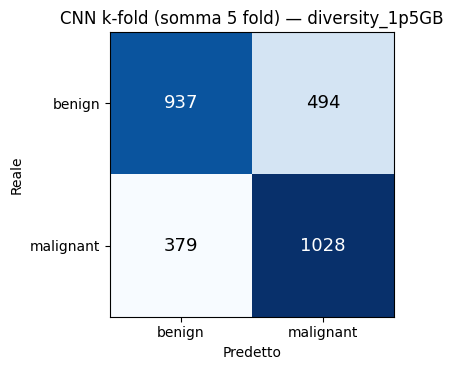

Recall maligni aggregata (TP/(TP+FN)): 0.731


In [ ]:
# Confusion matrix aggregata sulle 5 fold (solo CNN) per lettura D2
cnn_kf = df[(df.split_type=='kfold_patient_wise') & (df.model=='baseline_cnn')]
tn, fp, fn, tp = [int(cnn_kf[c].sum()) for c in ('tn','fp','fn','tp')]
cm = np.array([[tn, fp], [fn, tp]])

fig, ax = plt.subplots(figsize=(4.2, 3.8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1], ['benign','malignant']); ax.set_yticks([0,1], ['benign','malignant'])
ax.set_xlabel('Predetto'); ax.set_ylabel('Reale')
ax.set_title(f'CNN k-fold (somma 5 fold) — {CONFIG_NAME}')
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max()/2 else 'black', fontsize=13)
fig.tight_layout()
fig.savefig(FIGURES_DIR/'cnn_kfold_confusion_matrix.png', dpi=150)
plt.show()
print('Recall maligni aggregata (TP/(TP+FN)):', round(tp/(tp+fn), 3))

## Sezione 9 — Lettura dei risultati per D2

- **image-wise**: stima potenzialmente **ottimistica** (patch dello stesso paziente possono ricadere sia in train sia in test); utile solo come limite superiore, non come misura di generalizzazione.
- **patient-wise (singolo split)**: più rigoroso, ma con circa 5 pazienti in test la varianza è alta e un singolo valore non è affidabile.
- **k-fold patient-wise (media ± std)**: è il riferimento per D2. La deviazione standard tra le fold quantifica l'incertezza dovuta al basso numero di pazienti e va **sempre** riportata accanto alla media.
- Per la classe maligna si privilegia **recall_malignant** (sensibilità): in ambito clinico un falso negativo pesa più di un falso positivo.

**Confronto con il transfer learning (D1).** `cnn_baseline_metrics.csv` e la sintesi k-fold costituiscono i termini di paragone per il transfer learning valutato nel notebook 03, che deve usare **le stesse fold** per un confronto equo tra CNN da zero e transfer, a parità di split ed efficienza.

## Sezione 9b — Figure per la presentazione

Rigenera dai dati già salvati (`cnn_baseline_metrics.csv`, `training_log.csv`, `config.json`, `RUNS`) le cinque figure usate nelle slide di presentazione, così restano riproducibili dalla stessa pipeline invece che da uno script esterno. Richiede `df` caricato (Sezione 8) e `RUNS` enumerato (Sezione 6). Salva tutto in `results/02_baseline_cnn/figures/presentation_*.png`.

Questa sezione genera figure aggiuntive per la presentazione e per la lettura qualitativa dei risultati. Le figure sono derivate dai dati e dai log già prodotti nelle sezioni precedenti e non modificano metriche, predizioni o modelli.

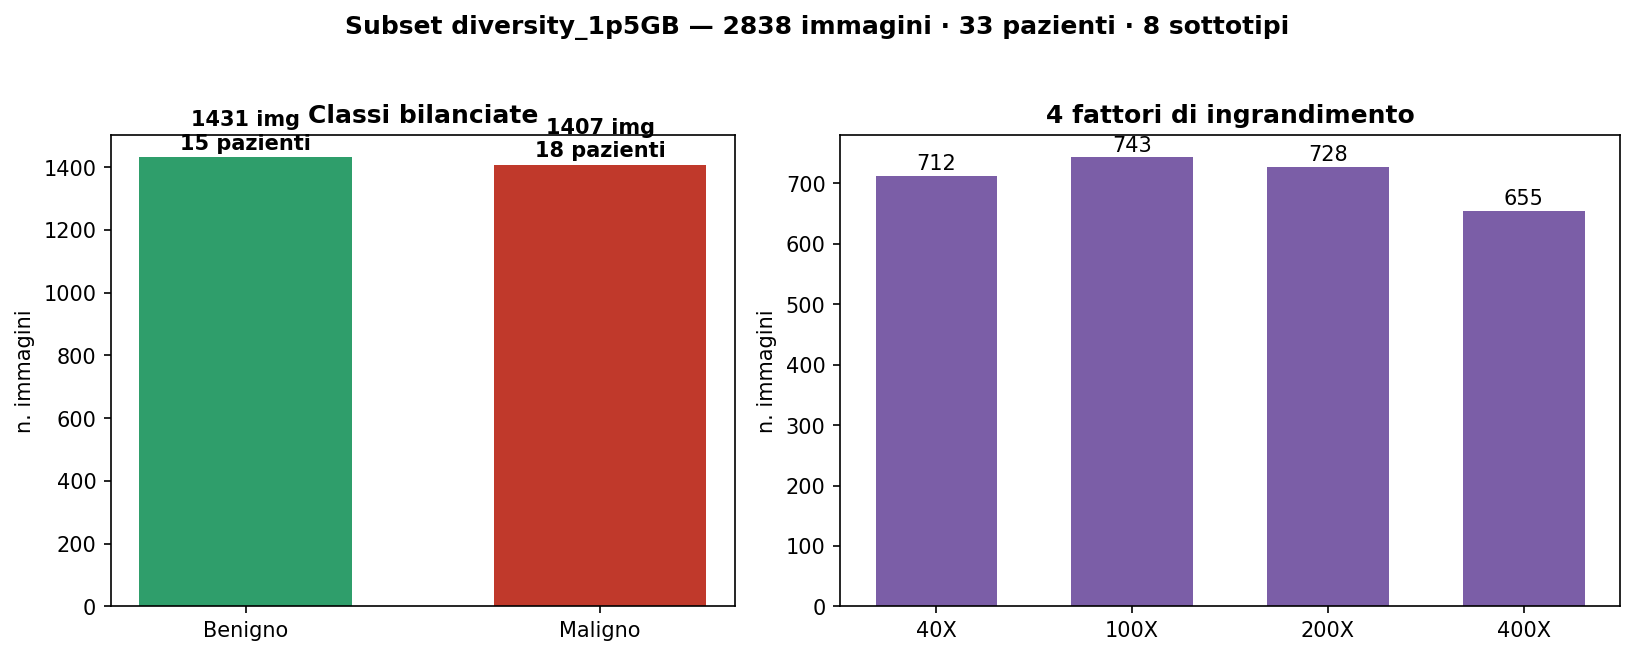

In [ ]:
# --- Composizione del subset (slide "Dataset") -------------------------------
with open(CONFIG_DIR/'config.json') as f:
    cfg_json = json.load(f)

C_BEN, C_MAL, C_MAG = '#2f9e6b', '#c0392b', '#7b5ea7'
mag_order = ['40X', '100X', '200X', '400X']

fig, (p1, p2) = plt.subplots(1, 2, figsize=(11, 4.2), dpi=150,
                             gridspec_kw={'width_ratios': [1, 1.25]})
imgs = [cfg_json['n_images_benign'], cfg_json['n_images_malignant']]
pats = [cfg_json['n_patients_benign'], cfg_json['n_patients_malignant']]
xb = np.arange(2)
p1.bar(xb, imgs, color=[C_BEN, C_MAL], width=0.6)
for i, (im, pa) in enumerate(zip(imgs, pats)):
    p1.annotate(f'{im} img\n{pa} pazienti', (xb[i], im), textcoords='offset points',
                xytext=(0, 4), ha='center', fontsize=10, fontweight='bold')
p1.set_xticks(xb); p1.set_xticklabels(['Benigno', 'Maligno'])
p1.set_ylabel('n. immagini'); p1.set_title('Classi bilanciate', fontweight='bold')

xm = np.arange(len(mag_order))
mag_counts = [cfg_json['magnifications'][m] for m in mag_order]
p2.bar(xm, mag_counts, color=C_MAG, width=0.62)
for i in range(len(mag_order)):
    p2.annotate(str(mag_counts[i]), (xm[i], mag_counts[i]), textcoords='offset points',
                xytext=(0, 3), ha='center', fontsize=10)
p2.set_xticks(xm); p2.set_xticklabels(mag_order)
p2.set_ylabel('n. immagini'); p2.set_title('4 fattori di ingrandimento', fontweight='bold')

fig.suptitle(f"Subset {CONFIG_NAME} — {cfg_json['n_images']} immagini · "
             f"{cfg_json['n_patients']} pazienti · {cfg_json['n_subtypes']} sottotipi",
             fontweight='bold', y=1.03)
fig.tight_layout()
fig.savefig(FIGURES_DIR/'presentation_dataset_composition.png', dpi=150, bbox_inches='tight')
plt.show()

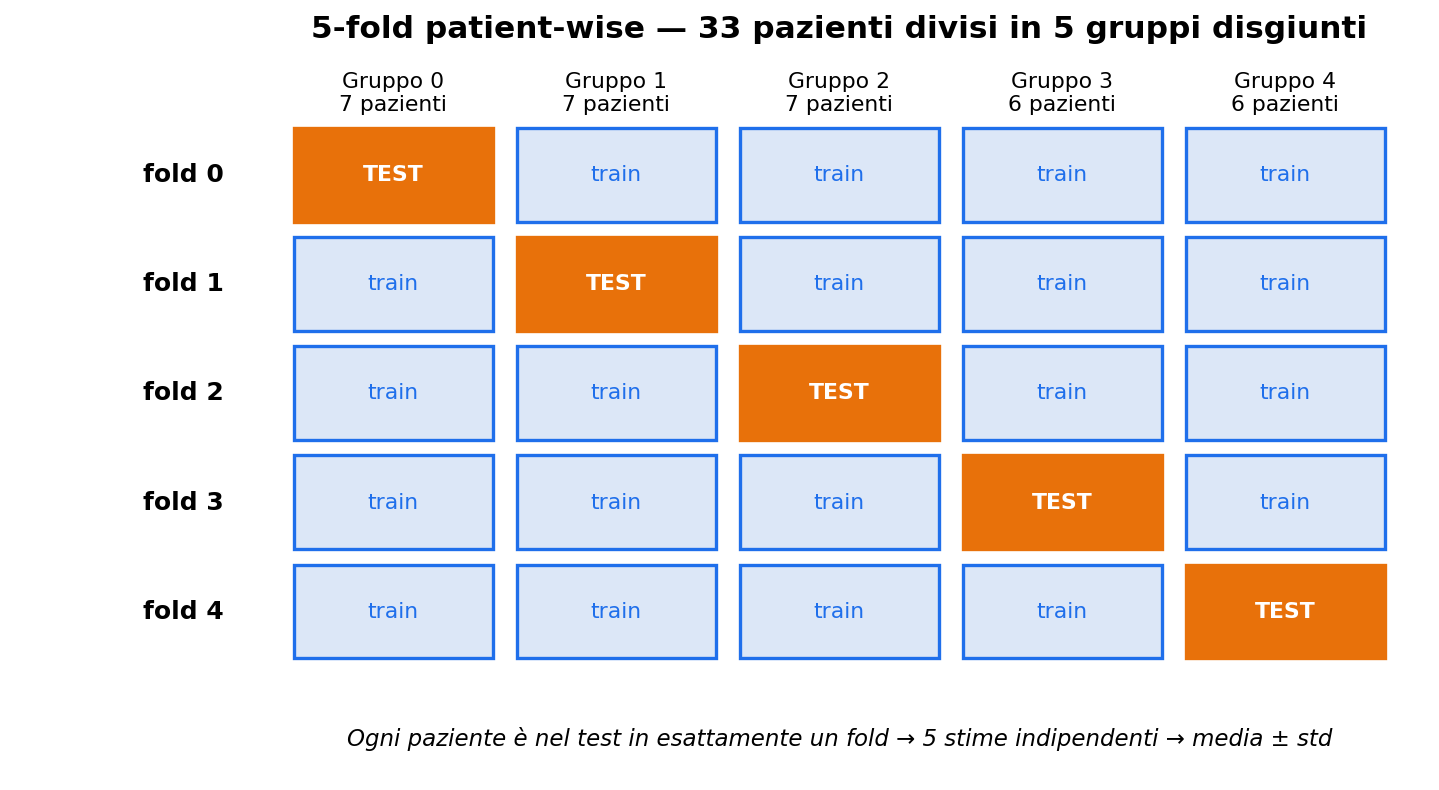

In [10]:
# --- Rotazione del 5-fold patient-wise (slide "Metodologia — valutazione") --
from matplotlib.patches import Rectangle

# Numero di pazienti nel test-set di ogni fold, letto direttamente da RUNS
# (Sezione 6): niente valori hard-coded, coerente con i dati correnti.
kfold_groups = {int(fo): te['patient_id'].nunique()
                for st, fo, tr, va, te in RUNS if st == 'kfold_patient_wise'}
n_folds = len(kfold_groups)
assert n_folds == 5, f'Attese 5 fold, trovate {n_folds}'

C_TEST, C_TRAINF, C_TRAINE = '#e8710a', '#dce7f7', '#1f6feb'
cell_w, cell_h, gap = 1.0, 0.72, 0.12

fig, ax = plt.subplots(figsize=(10, 5.4), dpi=150)
for fold in range(n_folds):
    y = (n_folds - 1 - fold) * (cell_h + gap)
    for g in range(n_folds):
        x = g * (cell_w + gap)
        is_test = (g == fold)
        ax.add_patch(Rectangle((x, y), cell_w, cell_h,
                     facecolor=C_TEST if is_test else C_TRAINF,
                     edgecolor=C_TEST if is_test else C_TRAINE, linewidth=1.6))
        ax.text(x + cell_w/2, y + cell_h/2, 'TEST' if is_test else 'train',
                ha='center', va='center', fontsize=10.5,
                fontweight='bold' if is_test else 'normal',
                color='white' if is_test else C_TRAINE)
    ax.text(-0.35, y + cell_h/2, f'fold {fold}', ha='right', va='center',
            fontsize=12, fontweight='bold')

top_y = n_folds * (cell_h + gap) - gap + 0.10
for g in range(n_folds):
    x = g * (cell_w + gap)
    ax.text(x + cell_w/2, top_y, f'Gruppo {g}\n{kfold_groups[g]} pazienti',
            ha='center', va='bottom', fontsize=10.5)

total_w = n_folds * (cell_w + gap) - gap
ax.set_xlim(-1.4, total_w + 0.2); ax.set_ylim(-0.9, top_y + 0.75); ax.axis('off')
n_pat_total = sum(kfold_groups.values())
ax.text(total_w/2, top_y + 0.55,
        f'5-fold patient-wise — {n_pat_total} pazienti divisi in 5 gruppi disgiunti',
        ha='center', va='bottom', fontsize=15, fontweight='bold')
ax.text(total_w/2, -0.62,
        "Ogni paziente è nel test in esattamente un fold → 5 stime indipendenti → media ± std",
        ha='center', va='center', fontsize=11, style='italic')

fig.tight_layout()
fig.savefig(FIGURES_DIR/'presentation_kfold_rotation.png', dpi=150, bbox_inches='tight')
plt.show()

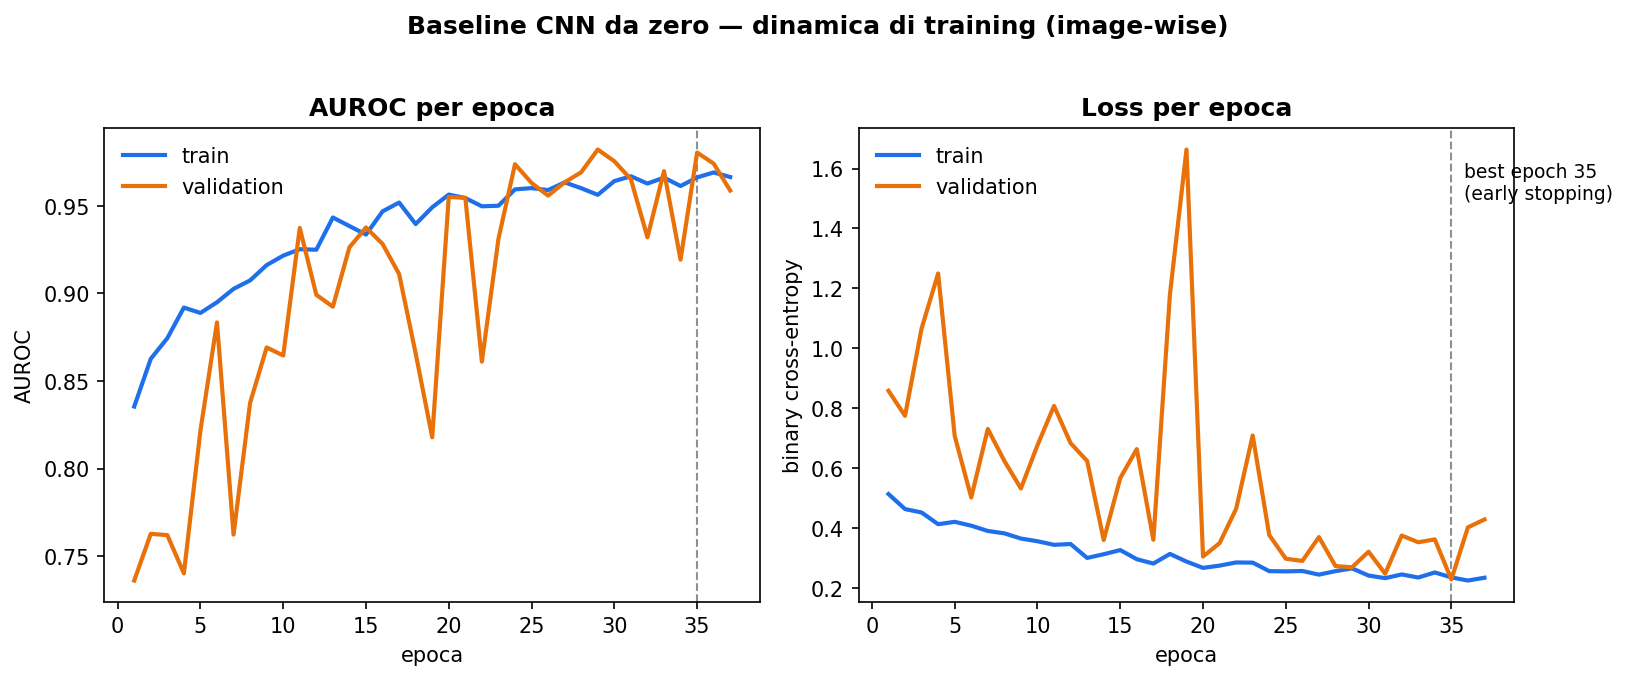

In [11]:
# --- Dinamica di training della baseline, run image-wise (slide "Metodologia — modello") ---
iw_row = df[(df.split_type == 'image_wise') & (df.model == 'baseline_cnn')].iloc[0]
log = pd.read_csv(EXPERIMENTS_DIR/iw_row['experiment']/'training_log.csv')
best_ep = int(log.loc[log['val_loss'].idxmin(), 'epoch'])

C_TRAIN, C_VAL = '#1f6feb', '#e8710a'
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.4), dpi=150)
for ax in (a1, a2):
    ax.axvline(best_ep, color='#5b616b', ls='--', lw=1, alpha=0.7)

a1.plot(log['epoch'], log['auc'], color=C_TRAIN, lw=2, label='train')
a1.plot(log['epoch'], log['val_auc'], color=C_VAL, lw=2, label='validation')
a1.set_title('AUROC per epoca', fontweight='bold'); a1.set_xlabel('epoca'); a1.set_ylabel('AUROC')
a1.legend(frameon=False)

a2.plot(log['epoch'], log['loss'], color=C_TRAIN, lw=2, label='train')
a2.plot(log['epoch'], log['val_loss'], color=C_VAL, lw=2, label='validation')
a2.set_title('Loss per epoca', fontweight='bold'); a2.set_xlabel('epoca'); a2.set_ylabel('binary cross-entropy')
a2.legend(frameon=False)
a2.annotate(f'best epoch {best_ep}\n(early stopping)', (best_ep, log['val_loss'].max() * 0.9),
            fontsize=9, ha='left', xytext=(6, 0), textcoords='offset points')

fig.suptitle('Baseline CNN da zero — dinamica di training (image-wise)', fontweight='bold', y=1.02)
fig.tight_layout()
fig.savefig(FIGURES_DIR/'presentation_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

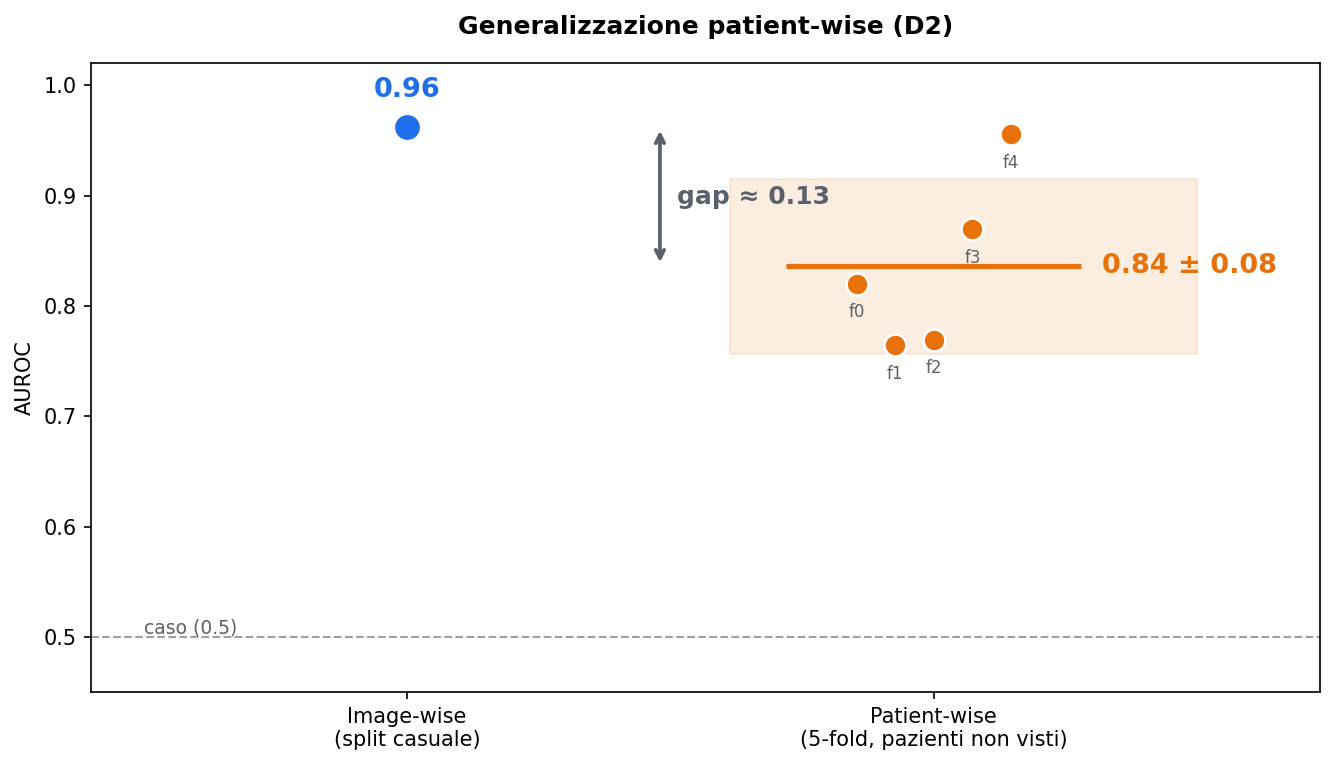

image-wise=0.9626  patient-wise=0.8358±0.0794  gap=0.1268


In [12]:
# --- D2: gap image-wise vs patient-wise (slide "Risultati D2") --------------
image_wise_auroc = df[(df.split_type == 'image_wise') & (df.model == 'baseline_cnn')]['auroc'].iloc[0]
kfold_aurocs = (df[(df.split_type == 'kfold_patient_wise') & (df.model == 'baseline_cnn')]
                .sort_values('fold')['auroc'].to_numpy())
mean_pw, std_pw = kfold_aurocs.mean(), kfold_aurocs.std(ddof=1)
gap = image_wise_auroc - mean_pw

C_IMG, C_PW, C_GREY = '#1f6feb', '#e8710a', '#5b616b'
x_img, x_pw = 0.9, 2.4
fig, ax = plt.subplots(figsize=(9, 5.2), dpi=150)
ax.scatter([x_img], [image_wise_auroc], s=180, color=C_IMG, zorder=5, edgecolor='white', linewidth=1.5)
ax.annotate(f'{image_wise_auroc:.2f}', (x_img, image_wise_auroc), textcoords='offset points',
            xytext=(0, 14), ha='center', fontsize=13, fontweight='bold', color=C_IMG)

ax.axhspan(mean_pw - std_pw, mean_pw + std_pw, xmin=0.52, xmax=0.90, color=C_PW, alpha=0.12)
ax.hlines(mean_pw, x_pw - 0.42, x_pw + 0.42, color=C_PW, lw=2.5)
jitter = np.linspace(-0.22, 0.22, len(kfold_aurocs))
ax.scatter(x_pw + jitter, kfold_aurocs, s=110, color=C_PW, zorder=5, edgecolor='white', linewidth=1.2)
for xj, val, i in zip(x_pw + jitter, kfold_aurocs, range(len(kfold_aurocs))):
    ax.annotate(f'f{i}', (xj, val), textcoords='offset points', xytext=(0, -16),
                ha='center', fontsize=8, color=C_GREY)
ax.annotate(f'{mean_pw:.2f} ± {std_pw:.2f}', (x_pw + 0.42, mean_pw), textcoords='offset points',
            xytext=(10, 0), va='center', ha='left', fontsize=13, fontweight='bold', color=C_PW)

ax.axhline(0.5, color=C_GREY, lw=1, ls='--', alpha=0.6)
ax.annotate('caso (0.5)', (0.15, 0.5), fontsize=9, color=C_GREY, va='bottom', ha='left')
ax.annotate('', xy=(1.62, image_wise_auroc), xytext=(1.62, mean_pw),
            arrowprops=dict(arrowstyle='<->', color=C_GREY, lw=1.8))
ax.annotate(f'gap ≈ {gap:.2f}', (1.62, (image_wise_auroc + mean_pw) / 2), textcoords='offset points',
            xytext=(8, 0), va='center', ha='left', fontsize=12, fontweight='bold', color=C_GREY)

ax.set_xlim(0, 3.5); ax.set_ylim(0.45, 1.02)
ax.set_xticks([x_img, x_pw])
ax.set_xticklabels(['Image-wise\n(split casuale)', 'Patient-wise\n(5-fold, pazienti non visti)'])
ax.set_ylabel('AUROC'); ax.set_title('Generalizzazione patient-wise (D2)', fontweight='bold', pad=14)
fig.tight_layout()
fig.savefig(FIGURES_DIR/'presentation_d2_image_vs_patient_wise.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'image-wise={image_wise_auroc:.4f}  patient-wise={mean_pw:.4f}±{std_pw:.4f}  gap={gap:.4f}')

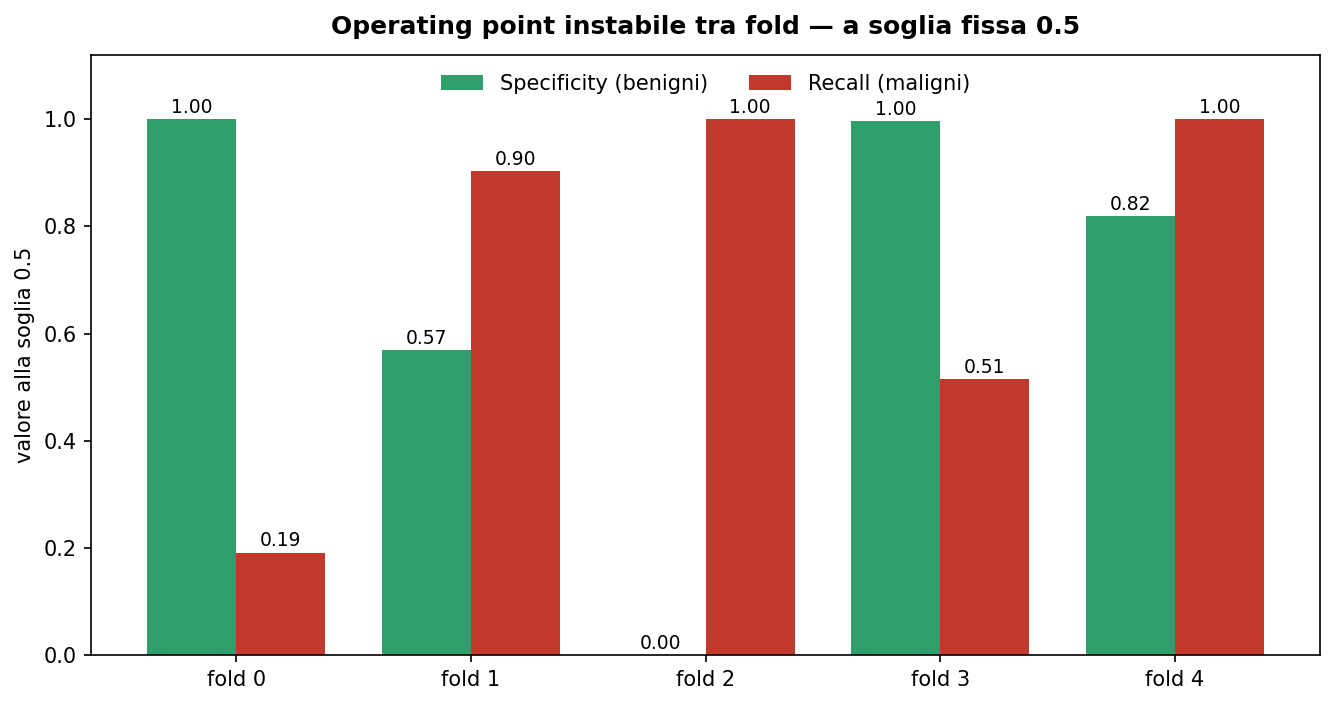

In [13]:
# --- Instabilità dell'operating point a soglia 0.5 tra fold (slide Backup) --
kf_cnn = df[(df.split_type == 'kfold_patient_wise') & (df.model == 'baseline_cnn')].sort_values('fold')
spec = kf_cnn['tn'] / (kf_cnn['tn'] + kf_cnn['fp'])
sens = kf_cnn['tp'] / (kf_cnn['tp'] + kf_cnn['fn'])
folds_lbl = [f'fold {int(fo)}' for fo in kf_cnn['fold']]

C_BEN, C_MAL = '#2f9e6b', '#c0392b'
x = np.arange(len(folds_lbl)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.8), dpi=150)
ax.bar(x - w/2, spec, w, color=C_BEN, label='Specificity (benigni)')
ax.bar(x + w/2, sens, w, color=C_MAL, label='Recall (maligni)')
for i in range(len(folds_lbl)):
    ax.annotate(f'{spec.iloc[i]:.2f}', (x[i] - w/2, spec.iloc[i]), textcoords='offset points',
                xytext=(0, 3), ha='center', fontsize=9)
    ax.annotate(f'{sens.iloc[i]:.2f}', (x[i] + w/2, sens.iloc[i]), textcoords='offset points',
                xytext=(0, 3), ha='center', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(folds_lbl)
ax.set_ylabel('valore alla soglia 0.5'); ax.set_ylim(0, 1.12)
ax.set_title('Operating point instabile tra fold — a soglia fissa 0.5', fontweight='bold', pad=10)
ax.legend(frameon=False, ncol=2, loc='upper center')
fig.tight_layout()
fig.savefig(FIGURES_DIR/'presentation_operating_point_instability.png', dpi=150, bbox_inches='tight')
plt.show()

## Output prodotti

- `results/02_baseline_cnn/tables/cnn_baseline_metrics.csv`: metriche complete per ogni run (schema fisso).
- `results/02_baseline_cnn/tables/cnn_baseline_kfold_summary.csv`: sintesi media ± std sulle 5 fold.
- `results/02_baseline_cnn/predictions/cnn_baseline_predictions.csv`: predizioni per immagine (out-of-fold) della baseline.
- `results/02_baseline_cnn/figures/cnn_kfold_confusion_matrix.png`: confusion matrix aggregata sulle 5 fold.
- `results/02_baseline_cnn/figures/presentation_dataset_composition.png`: composizione del subset (classi, magnification).
- `results/02_baseline_cnn/figures/presentation_kfold_rotation.png`: schema di rotazione del 5-fold patient-wise.
- `results/02_baseline_cnn/figures/presentation_training_curves.png`: curve di training AUROC/loss (run image-wise).
- `results/02_baseline_cnn/figures/presentation_d2_image_vs_patient_wise.png`: gap image-wise vs patient-wise per D2.
- `results/02_baseline_cnn/figures/presentation_operating_point_instability.png`: specificity/recall per fold a soglia 0.5.
- `experiments/<timestamp>_.../`: una cartella per run con `config.json`, `model.keras`, `training_log.csv` e `metrics.csv`.

Questi file costituiscono la baseline di riferimento per il confronto con il transfer learning del notebook 03, da valutare sulle stesse fold.